# Lectura de datos (CICIDS2017):
- Hay un total de 79 columnas para la selección de datos
- Se quiere ver cuales son los features que van ayudar más al modelo y que features agregarle al modelo de deep learning

In [1]:
import pandas as pd
import numpy as np
import os

path = r'C:\Users\Felix\Desktop\Tesis\Datasets\Datasets_listos\CICIDS2017.parquet'

df = pd.read_parquet(path)
    
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

In [3]:
import pandas as pd
import numpy as np

constant_cols= [col for  col in df.columns if df[col].nunique()<=1]
print(f"🚩 Columnas constantes detectadas ({len(constant_cols)}):")
print(constant_cols)


🚩 Columnas constantes detectadas (8):
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular asimetría (Skewness) solo en numéricas
skewness_values = df.select_dtypes(include=[np.number]).skew().sort_values(ascending=False)

print("📊 Top 10 características con mayor sesgo:")
print(skewness_values.head(10))

# Visualizar la distribución de una característica clave (ej. Flow Duration)
# Usamos una muestra de 100k para no saturar la gráfica
sample_df = df.sample(n=min(100000, len(df)), random_state=42)

plt.figure(figsize=(10, 5))
sns.histplot(data=sample_df, x='', hue='Label', kde=True, element="step")
plt.title("Distribución de Característica por Clase")
plt.yscale('log') # Escala logarítmica es vital en redes
plt.show()

📊 Top 10 características con mayor sesgo:
Total Length of Fwd Packets    805.570539
Subflow Fwd Bytes              803.598592
act_data_pkt_fwd               284.595228
Subflow Bwd Packets            244.679507
Total Backward Packets         244.679507
Total Fwd Packets              244.380553
Subflow Fwd Packets            244.380553
Subflow Bwd Bytes              244.335301
Total Length of Bwd Packets    244.330893
CWE Flag Count                  94.781303
dtype: float64


ValueError: Could not interpret value `tu_columna_aqui` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

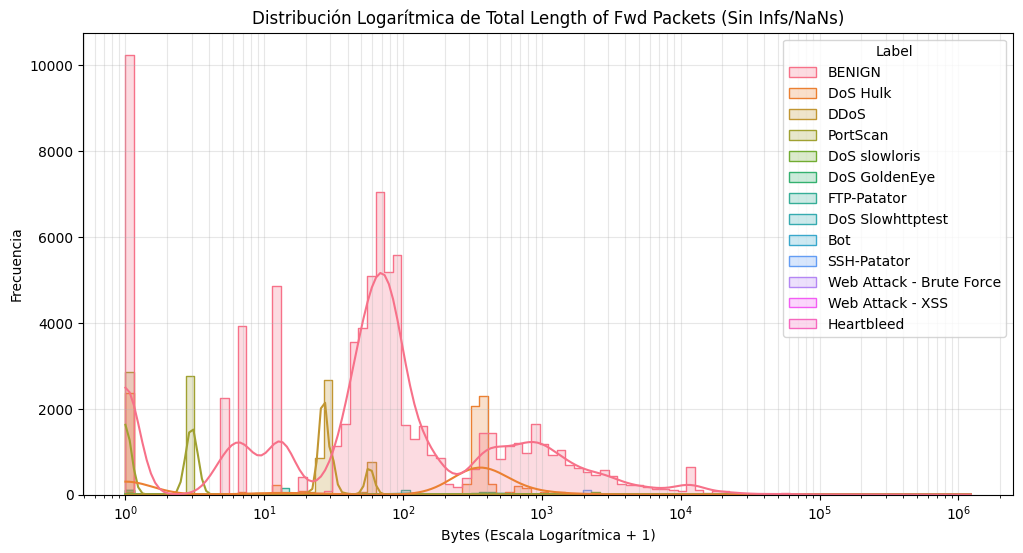

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tomamos la muestra
sample_df = df.sample(n=min(100000, len(df)), random_state=42).copy()

# 2. LIMPIEZA RÁPIDA PARA LA GRÁFICA
# Reemplazamos inf por NaN y luego eliminamos las filas con NaN en la columna que queremos ver
col_interes = 'Total Length of Fwd Packets'
sample_df[col_interes] = sample_df[col_interes].replace([np.inf, -np.inf], np.nan)
plot_data = sample_df.dropna(subset=[col_interes, 'Label'])

# 3. GRAFICAR
plt.figure(figsize=(12, 6))

# Usamos log_scale=(10, False) para que solo el eje X sea logarítmico
# Añadimos un pequeño valor (1) para evitar el log(0) si hay flujos de 0 bytes
sns.histplot(
    data=plot_data, 
    x=plot_data[col_interes] + 1, # El +1 evita errores con ceros
    hue='Label', 
    kde=True, 
    element="step", 
    log_scale=True
)

plt.title(f"Distribución Logarítmica de {col_interes} (Sin Infs/NaNs)")
plt.xlabel("Bytes (Escala Logarítmica + 1)")
plt.ylabel("Frecuencia")
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()